In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import joblib

INPUT DATASET

In [23]:
df = pd.read_csv('dataset/data_kalimat_berlabel.csv')

BAGIAN KOLOM

In [24]:
X = df['Kalimat'] 
y = df['Tingkat Pemahaman']

MEMBAGI DATA TRAIN DAN TEST

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Jumlah data latih: {len(X_train)} baris")
print(f"Jumlah data uji: {len(X_test)} baris\n")

Jumlah data latih: 1000 baris
Jumlah data uji: 250 baris



MEMBUAT MODEL

In [26]:
# model_pipeline = Pipeline([
#     ('vectorizer', TfidfVectorizer()), 
#     ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
# ])

model_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()), 
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

LATIH MODEL

In [27]:
print("Memulai proses training model...")
model_pipeline.fit(X_train, y_train)
print("Training selesai!\n")

Memulai proses training model...
Training selesai!



EVALUASI MODEL

In [28]:
print("Hasil Evaluasi Model pada Data Uji:")
y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

Hasil Evaluasi Model pada Data Uji:
                   precision    recall  f1-score   support

 Belum Berkembang       0.64      0.33      0.44        27
Berkembang Sedang       0.74      0.87      0.80       114
      Sudah Mahir       0.89      0.84      0.87       109

         accuracy                           0.80       250
        macro avg       0.76      0.68      0.70       250
     weighted avg       0.80      0.80      0.79       250



VUSIALISASI EVALUASI MODEL

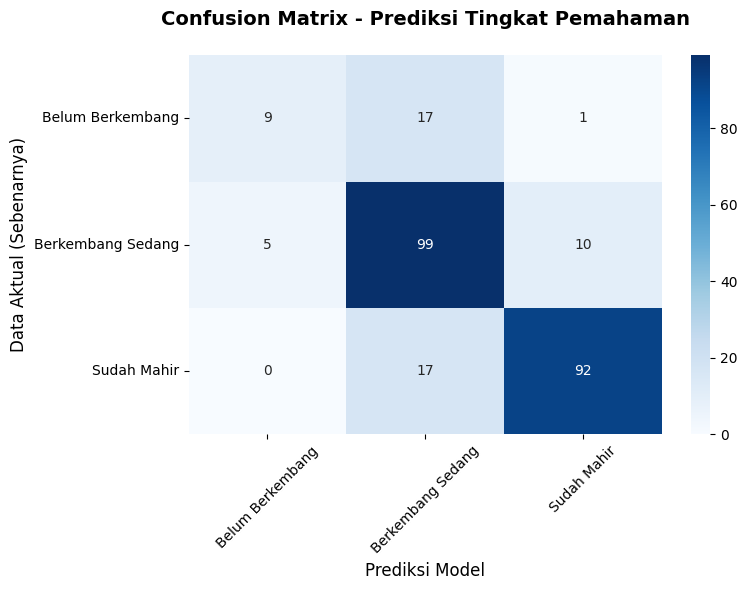

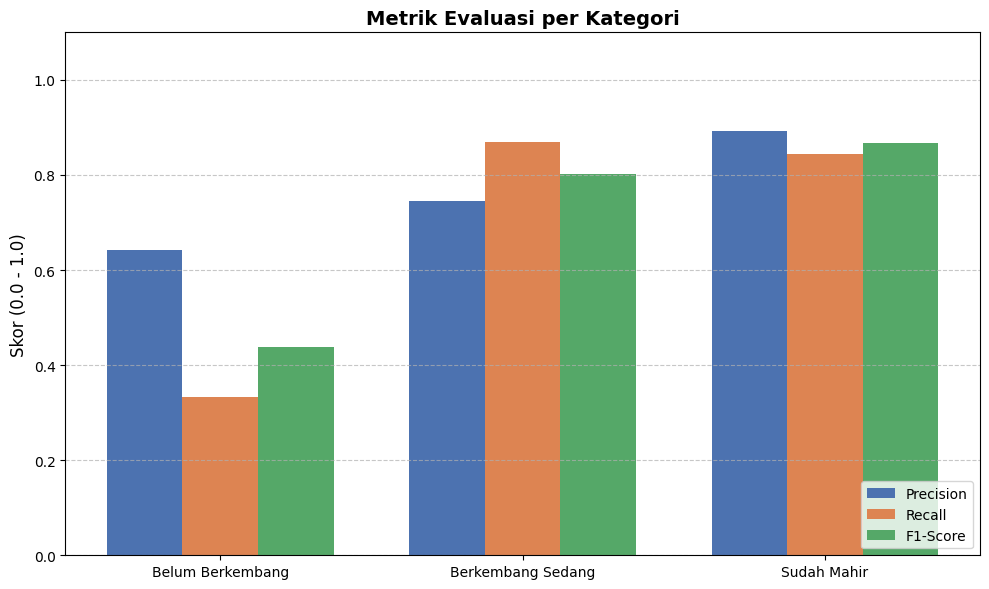

In [29]:
# Mengambil daftar label/kelas dari model
kelas_label = model_pipeline.classes_

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=kelas_label)

# 1. VISUALISASI CONFUSION MATRIX
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=kelas_label, 
            yticklabels=kelas_label)

plt.title('Confusion Matrix - Prediksi Tingkat Pemahaman\n', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Data Aktual (Sebenarnya)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. VISUALISASI CLASSIFICATION REPORT (BAR CHART)
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=kelas_label)

x = np.arange(len(kelas_label))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='#4C72B0')
plt.bar(x, recall, width, label='Recall', color='#DD8452')
plt.bar(x + width, f1, width, label='F1-Score', color='#55A868')

plt.ylabel('Skor (0.0 - 1.0)', fontsize=12)
plt.title('Metrik Evaluasi per Kategori', fontsize=14, fontweight='bold')
plt.xticks(x, kelas_label)
plt.legend(loc='lower right')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

IMPORT MODEL KE FORMAT STREAMLIT

In [ ]:
nama_file_model = 'model_sintaksis.pkl' 
joblib.dump(model_pipeline, nama_file_model)
print(f"Sukses! Model telah disimpan dengan nama '{nama_file_model}'")

Sukses! Model telah disimpan dengan nama 'model_sintaksis.pkl'
